<a href="https://colab.research.google.com/github/23071234-coder/NNDL/blob/main/Prac6_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (2000, 20, 1)
Training data: (1600, 20, 1)
Testing data: (400, 20, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 20, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 20, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 1)          │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281 (12.82 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.5002 - val_loss: 0.4947
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4873 - val_loss: 0.4741
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4713 - val_loss: 0.4636
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4600 - val_loss: 0.4472
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4356 - val_loss: 0.4089
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3945 - val_loss: 0.3701
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3629 - val_loss: 0.3393
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3370 - val_loss: 0.3156
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3112 - val_loss: 0.2871
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2923 - val_loss: 0.2665
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2583 - val_loss: 0.2407
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2325 - va

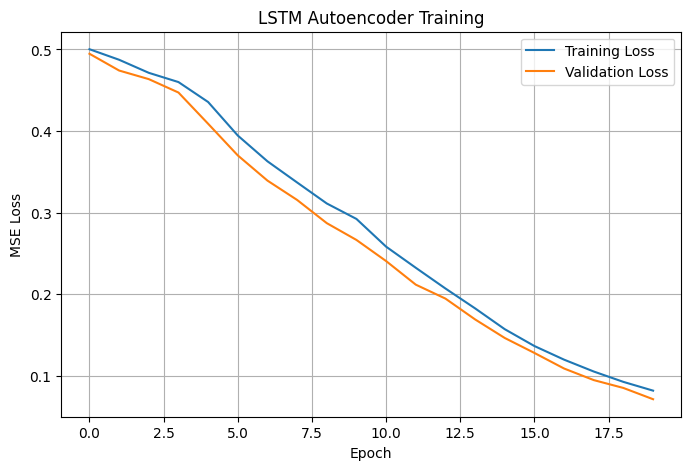

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Original shape: (400, 20, 1)
Reconstructed shape: (400, 20, 1)


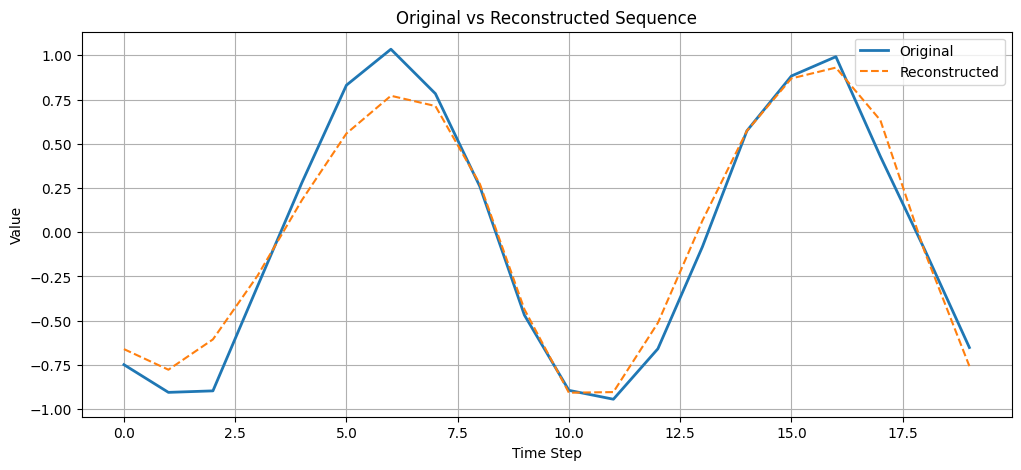

Mean reconstruction error: 0.06455523076401154
Maximum reconstruction error: 0.47072688780516103
Anomaly threshold: 0.2333898150447659
Number of anomalies: 20
Total test samples: 400


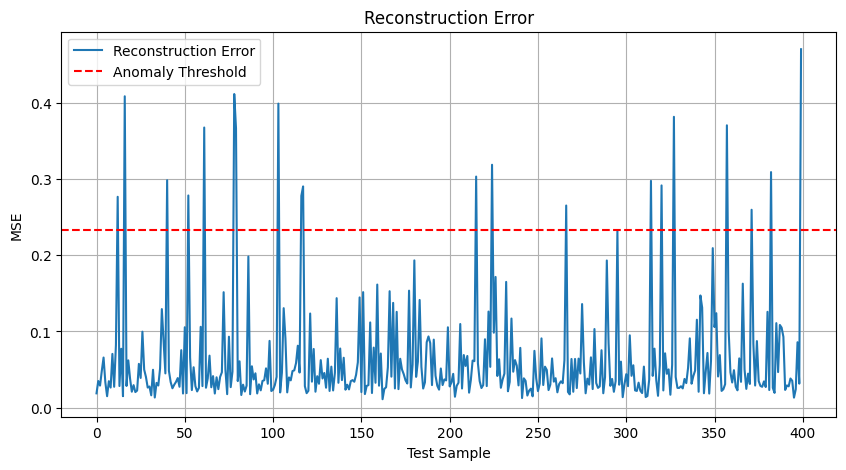

In [ ]:
# 1. Import libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.model_selection import train_test_split


# 2. Generate sequential data

np.random.seed(42)
tf.random.set_seed(42)

n_samples = 2000
timesteps = 20
features = 1

X = []

for i in range(n_samples):
    phase = np.random.uniform(0, 2 * np.pi)
    x = np.linspace(0, 4 * np.pi, timesteps)

    sequence = np.sin(x + phase)
    sequence += np.random.normal(0, 0.05, timesteps)

    X.append(sequence)

X = np.array(X)
X = X.reshape(n_samples, timesteps, features)

print("Dataset shape:", X.shape)


# 3. Split the data

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


# 4. Build the LSTM Autoencoder

latent_dim = 16

inputs = Input(shape=(timesteps, features))

encoded = LSTM(
    latent_dim,
    activation='tanh'
)(inputs)

decoded = RepeatVector(timesteps)(encoded)

decoded = LSTM(
    latent_dim,
    activation='tanh',
    return_sequences=True
)(decoded)

outputs = TimeDistributed(
    Dense(features)
)(decoded)

autoencoder = Model(inputs, outputs)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()


# 5. Train the Autoencoder

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)


# 6. Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Autoencoder Training')
plt.legend()
plt.grid(True)
plt.show()


# 7. Reconstruct test sequences

X_pred = autoencoder.predict(X_test)

print("Original shape:", X_test.shape)
print("Reconstructed shape:", X_pred.shape)


# 8. Visualize reconstruction

plt.figure(figsize=(12, 5))

plt.plot(
    X_test[0, :, 0],
    label='Original',
    linewidth=2
)

plt.plot(
    X_pred[0, :, 0],
    label='Reconstructed',
    linestyle='--'
)

plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Original vs Reconstructed Sequence')
plt.legend()
plt.grid(True)

plt.show()


# 9. Calculate reconstruction error

reconstruction_error = np.mean(
    np.square(X_test - X_pred),
    axis=(1, 2)
)

print(
    "Mean reconstruction error:",
    np.mean(reconstruction_error)
)

print(
    "Maximum reconstruction error:",
    np.max(reconstruction_error)
)


# 10. Detect anomalies

threshold = np.percentile(
    reconstruction_error,
    95
)

print("Anomaly threshold:", threshold)

anomalies = reconstruction_error > threshold

print("Number of anomalies:", np.sum(anomalies))
print("Total test samples:", len(X_test))


# 11. Plot reconstruction errors

plt.figure(figsize=(10, 5))

plt.plot(
    reconstruction_error,
    label='Reconstruction Error'
)

plt.axhline(
    threshold,
    color='red',
    linestyle='--',
    label='Anomaly Threshold'
)

plt.xlabel('Test Sample')
plt.ylabel('MSE')
plt.title('Reconstruction Error')
plt.legend()
plt.grid(True)

plt.show()
